## ***Title: Diwali Sales Data Analysis***
This project analyzes Diwali sales data using Python libraries such as Pandas and Matplotlib. The objective is to understand customer purchasing behavior, sales trends, and product demand during the festive season.

___________________________________________________________________________________________________________________
___

### Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset

In [12]:
url = r"..\Datasets\Diwali_Sales.csv"
df=pd.read_csv(url,encoding="unicode_escape")

#### Data inspection

In [13]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.9 MB


In [15]:
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(8)

___________________________________________________________________________________________________________________
___

### Data Cleaning and Preprocessing

In [17]:
df.drop(columns=["Status","unnamed1"],inplace=True)
np.shape(df)

(11251, 13)

In [18]:
df.dropna(subset="Amount",inplace=True)

In [19]:
df.drop_duplicates(inplace=True)
np.shape(df)

(11231, 13)

In [20]:
df["Amount"]=df["Amount"].astype("int")
df["Amount"].dtype

dtype('int64')

In [21]:
df.info() #Rechecking

<class 'pandas.DataFrame'>
Index: 11231 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   User_ID           11231 non-null  int64
 1   Cust_name         11231 non-null  str  
 2   Product_ID        11231 non-null  str  
 3   Gender            11231 non-null  str  
 4   Age Group         11231 non-null  str  
 5   Age               11231 non-null  int64
 6   Marital_Status    11231 non-null  int64
 7   State             11231 non-null  str  
 8   Zone              11231 non-null  str  
 9   Occupation        11231 non-null  str  
 10  Product_Category  11231 non-null  str  
 11  Orders            11231 non-null  int64
 12  Amount            11231 non-null  int64
dtypes: int64(5), str(8)
memory usage: 1.9 MB


___________________________________________________________________________________________________________________
___

### Exploratory Data Analysis

#### 1. Gender Analysis

##### A) Male vs Female shoppers count

In [22]:
shoppers_count=df["Gender"].value_counts()
print("Male vs Female shoppers count:\n",shoppers_count)

Male vs Female shoppers count:
 Gender
F    7828
M    3403
Name: count, dtype: int64


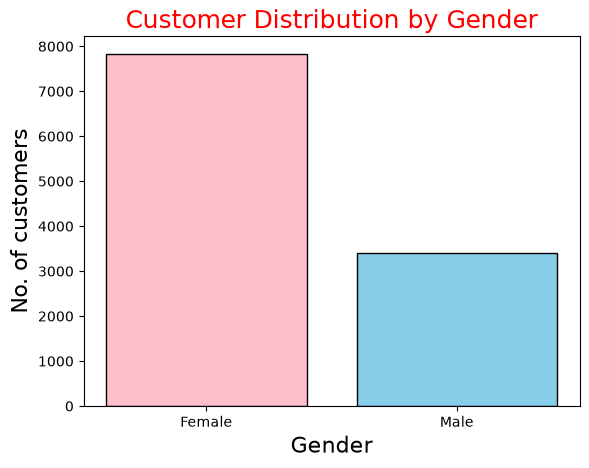

In [23]:
plt.bar(shoppers_count.index,shoppers_count.values,color=["pink","skyblue"],edgecolor="black")
plt.title("Customer Distribution by Gender",fontsize=18,color='red')
plt.xlabel('Gender',fontsize=16)
plt.ylabel('No. of customers',fontsize=16)
plt.xticks([0,1],["Female","Male"])
plt.show()

Observation:

Female customers are higher in number compared to male customers, indicating that women are more active shoppers during the Diwali season.

__

##### B) Total amount spent by gender

In [24]:
shoppers_spent=df.groupby("Gender")["Amount"].sum()
print("Total amount spent by both genders :\n",shoppers_spent)

Total amount spent by both genders :
 Gender
F    74307679
M    31871146
Name: Amount, dtype: int64


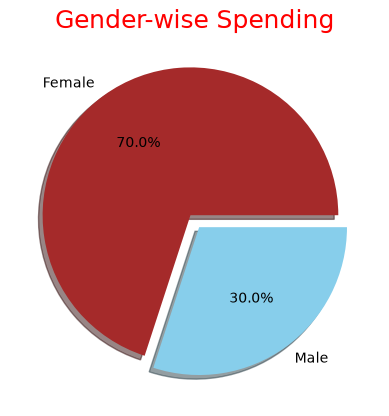

In [25]:
plt.pie(shoppers_spent.values,labels=["Female",'Male'],colors=["brown","skyblue"],autopct="%1.1f%%",explode=[0.05,0.05],shadow=True)
plt.title("Gender-wise Spending",fontsize=18,color='red')
plt.show()

Observation:

Female customers contribute more to the total sales amount, showing higher purchasing power and spending behavior.

___

#### 2. Age Group Analysis

In [26]:
age_groups_count=df["Age Group"].value_counts()
print("NO. of customers of Different Age Groups:\n",age_groups_count)

NO. of customers of Different Age Groups:
 Age Group
26-35    4536
36-45    2282
18-25    1878
46-50     983
51-55     829
55+       427
0-17      296
Name: count, dtype: int64


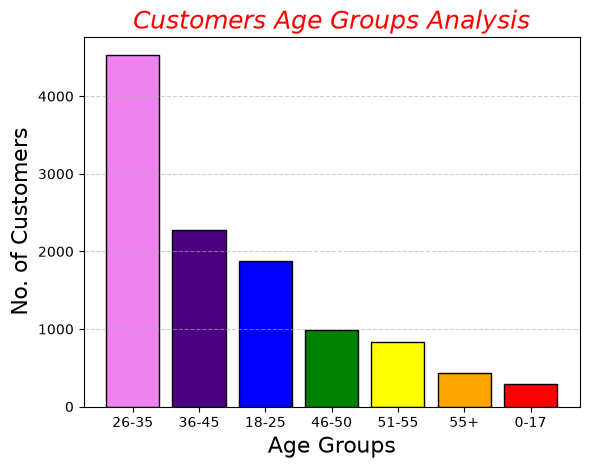

In [27]:
plt.bar(age_groups_count.index,age_groups_count.values,color=['violet','indigo','blue','green','yellow','orange','red'],edgecolor="black")
plt.title("Customers Age Groups Analysis",fontsize=18,color='red',fontstyle='italic')
plt.xlabel('Age Groups',fontsize=16)
plt.ylabel('No. of Customers',fontsize=16)
plt.grid(axis='y',alpha=0.6,linestyle="--")
plt.show()

Observation:

Customers belonging to the 26–35 years age group are the most active buyers. Young and middle-aged customers contribute significantly to festive shopping.

___

#### 3. State Analysis

In [28]:
states_revenue=df.groupby("State")["Amount"].sum().sort_values(ascending=False).head()
print("Revenue from different states:\n",states_revenue)

Revenue from different states:
 State
Uttar Pradesh     19346055
Maharashtra       14404467
Karnataka         13523540
Delhi             11603818
Madhya Pradesh     8101142
Name: Amount, dtype: int64


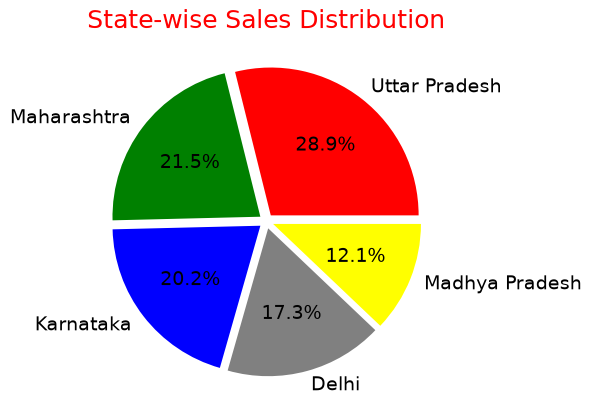

In [29]:
plt.pie(states_revenue.values,labels=states_revenue.index,colors=['red','green','blue','gray',"yellow"],autopct="%1.1f%%",explode=[0.05,0.05,0.05,0.05,0.05],textprops={"fontsize":14})
plt.title("State-wise Sales Distribution",fontsize=18,color='red')
plt.show()

Observation:

States such as Uttar Pradesh, Maharashtra, and Karnataka generate the highest sales revenue, indicating strong customer engagement in these regions.

___

#### 4. Occupation Analysis

In [30]:
occ_spending=df.groupby("Occupation")["Amount"].sum().sort_values(ascending=False).head()
print("spending amount from Customers with different Occupations :\n",occ_spending)

spending amount from Customers with different Occupations :
 Occupation
IT Sector     14741862
Healthcare    13034586
Aviation      12599994
Banking       10770610
Govt           8517212
Name: Amount, dtype: int64


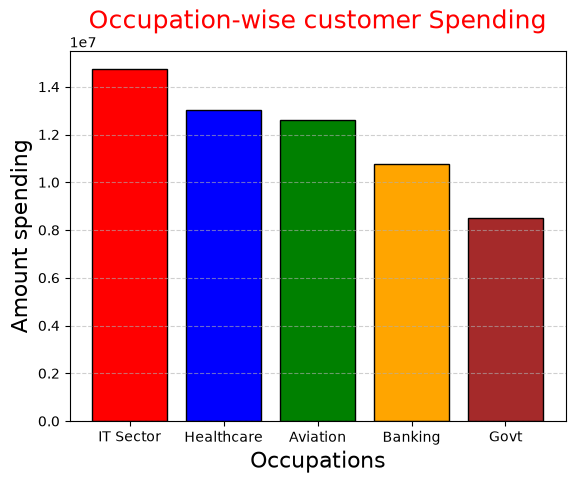

In [31]:
plt.bar(occ_spending.index,occ_spending.values,color=['red','blue','green','orange','brown'],edgecolor="black")
plt.title("Occupation-wise customer Spending",fontsize=18,color='red')
plt.xlabel('Occupations',fontsize=16)
plt.ylabel('Amount spending',fontsize=16)
plt.grid(axis='y',alpha=0.6,linestyle="--")
plt.show()

Observation:

Customers working in IT, Healthcare, and Aviation sectors contribute the highest revenue, suggesting higher purchasing capacity among these professions.

___

#### 5. Product Category Analysis

In [32]:
top_prod_categ=df["Product_Category"].value_counts().head()
print("Most popular Product Categories:\n",top_prod_categ )

Most popular Product Categories:
 Product_Category
Clothing & Apparel       2653
Food                     2490
Electronics & Gadgets    2082
Footwear & Shoes         1059
Household items           520
Name: count, dtype: int64


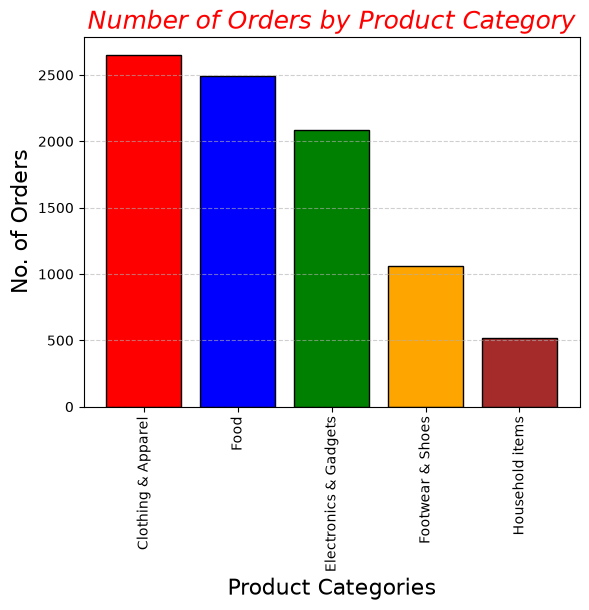

In [33]:
plt.bar(top_prod_categ.index,top_prod_categ.values,color=['red','blue','green','orange','brown'],edgecolor="black")
plt.title("Number of Orders by Product Category",fontsize=18,color='red',fontstyle="oblique")
plt.xlabel('Product Categories',fontsize=16)
plt.xticks(rotation=90)
plt.ylabel('No. of Orders',fontsize=16)
plt.grid(axis='y',alpha=0.6,linestyle="--")
plt.show()

Observation:

Product categories like Clothing, Food, and Electronics receive the highest number of orders, making them the most popular categories during the festive season.

___________________________________________________________________________________________________________________
---

### Conclusion

#### Ideal customer is:
	GENDER     ---> FEMALE

	Age Group  ---> 26-35 years

	States     ---> Uttar Pradesh,Maharashtra,Karnataka

	Occupation ---> IT,Healthcare,Aviation
___
#### Inventory Suggestion:
	Clothing/Apparel

	Food products

	Electronics

Because these categories generate the highest sales and order volume.
___
___
    






### Personal Observation

From the Diwali Sales dataset analysis, we observed that female customers between the age group of 26–35 years are the most active buyers. States like Uttar Pradesh and Maharashtra contribute maximum sales. Product categories such as Food, Clothing, and Electronics perform the best during festive seasons. This analysis helps businesses understand customer behavior and improve marketing and inventory planning.
___
___